第二章：数据清洗及特征处理

In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('C:/Users/22454/Desktop/code/data/train.csv')

In [ ]:
#缺失值观察的方法

#方法1
df.info()
#方法2
df.isnull().sum()

In [2]:
#处理缺失值，对age列

df[df['Age']==None]=0
df[df['Age'] == np.nan] = 0

数值列读取数据后，空缺值的数据类型为float64所以用None一般索引不到，比较的时候最好用np.nan

In [3]:
df.dropna().head(3)#缺失值删除
df.fillna(0).head(3)#缺失值填充

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S


重复值处理：

In [4]:
#查看数据中的重复值
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [5]:
#对整行重复值进行处理
df = df.drop_duplicates()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#清洗后的数据保存
df.to_csv('C:/Users/22454/Desktop/code/data/test_clear.csv')

数值型特征一般可以直接用于模型的训练，但有时候为了模型的稳定性及鲁棒性会对连续变量进行离散化。文本型特征往往需要转换成数值型特征才能用于建模分析。

In [7]:
#离散化处理
#将连续变量Age平均分箱成5个年龄段，并分别用类别变量12345表示
df['AgeBand'] = pd.cut(df['Age'], 5,labels = [1,2,3,4,5])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBand
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3


In [8]:
df.to_csv('C:/Users/22454/Desktop/code/data/test_ave.csv')

In [9]:
df['AgeBand'] = pd.cut(df['Age'],[0,5,15,30,50,80],labels = [1,2,3,4,5])
df.head(3)
df.to_csv('C:/Users/22454/Desktop/code/data/test_cut.csv')

In [10]:
#将连续变量Age按10% 30% 50 70% 90%五个年龄段，并用分类变量12345表示
df['AgeBand'] = pd.qcut(df['Age'],[0,0.1,0.3,0.5,0.7,0.9],labels = [1,2,3,4,5])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBand
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,5
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,4
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,4


In [ ]:
df.to_csv('C:/Users/22454/Desktop/code/data/test_pr.csv')

文本变量转换        
(1) 查看文本变量名及种类         
(2) 将文本变量Sex， Cabin ，Embarked用数值变量12345表示       
(3) 将文本变量Sex， Cabin， Embarked用one-hot编码表示         
未完成：https://github.com/datawhalechina/hands-on-data-analysis/blob/master/%E7%AC%AC%E4%BA%8C%E7%AB%A0%E9%A1%B9%E7%9B%AE%E9%9B%86%E5%90%88/%E7%AC%AC%E4%BA%8C%E7%AB%A0%EF%BC%9A%E7%AC%AC%E4%B8%80%E8%8A%82%E6%95%B0%E6%8D%AE%E6%B8%85%E6%B4%97%E5%8F%8A%E7%89%B9%E5%BE%81%E5%A4%84%E7%90%86.ipynb

数据重构：

In [11]:
text = pd.read_csv('C:/Users/22454/Desktop/code/data/train-left-up.csv')
text.head()

,PassengerId,Survived,Pclass,Name
0,1,0,3,"Braund, Mr. Owen Harris"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,3,1,3,"Heikkinen, Miss. Laina"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,5,0,3,"Allen, Mr. William Henry"


In [12]:
text_left_up = pd.read_csv("C:/Users/22454/Desktop/code/data/train-left-up.csv")
text_left_down = pd.read_csv("C:/Users/22454/Desktop/code/data/train-left-down.csv")
text_right_up = pd.read_csv("C:/Users/22454/Desktop/code/data/train-right-up.csv")
text_right_down = pd.read_csv("C:/Users/22454/Desktop/code/data/train-right-down.csv")

合并CSV表格

In [ ]:
#使用concat方法：将数据train-left-up.csv和train-right-up.csv横向合并为一张表，并保存这张表为result_up

In [13]:
list_up = [text_left_up,text_right_up]
result_up = pd.concat(list_up,axis=1)
result_up.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
list_down=[text_left_down,text_right_down]
result_down = pd.concat(list_down,axis=1)
result = pd.concat([result_up,result_down])
result.head()

#使用Panads的merge方法和DataFrame的append方法完成上述工作
# result_up = pd.merge(text_left_up,text_right_up,left_index=True,right_index=True)
# result_down = pd.merge(text_left_down,text_right_down,left_index=True,right_index=True)
# result = resul_up.append(result_down)
result.to_csv('C:/Users/22454/Desktop/code/data/result.csv')

In [16]:
text = pd.read_csv('result.csv')
text.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
#计算泰坦尼克号男性与女性的平均票价
df  = text['Fare'].groupby(text['Sex'])
means = df.mean()
means

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64

In [18]:
#统计泰坦尼克号中男女的存活人数
survived_sex = text['Survived'].groupby(text['Sex']).sum()
survived_sex.head()

Sex
female    233
male      109
Name: Survived, dtype: int64

In [19]:
#计算客舱不同等级的存活人数
survived_pclass = text['Survived'].groupby(text['Pclass'])
survived_pclass.sum()

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [20]:
#统计在不同等级的票中的不同年龄的船票花费的平均值
text.groupby(['Pclass','Age'])['Fare'].mean().head()

Pclass  Age  
1       0.92     151.5500
        2.00     151.5500
        4.00      81.8583
        11.00    120.0000
        14.00    120.0000
Name: Fare, dtype: float64

In [21]:
#将两个数据合并，并保存
result = pd.merge(means,survived_sex,on='Sex')
result.to_csv('sex_fare_survived.csv')

数据可视化部分：

In [22]:
text.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


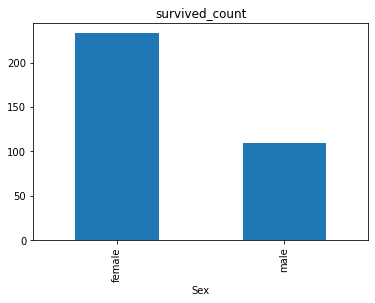

In [25]:
%matplotlib inline

import matplotlib.pyplot as plt
#柱状图可视化展示泰坦尼克号数据集中男女中生存人数分布情况
sex = text.groupby('Sex')['Survived'].sum()
sex.plot.bar()
plt.title('survived_count')
plt.show()

Text(0, 0.5, 'count')

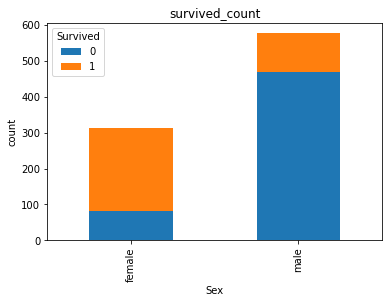

In [26]:
#柱状图可视化展示泰坦尼克号数据集中男女中生存人与死亡人数的比例图
# 计算男女中死亡人数 1表示生存，0表示死亡
text.groupby(['Sex','Survived'])['Survived'].count().unstack().plot(kind='bar',stacked='True')
plt.title('survived_count')
plt.ylabel('count')

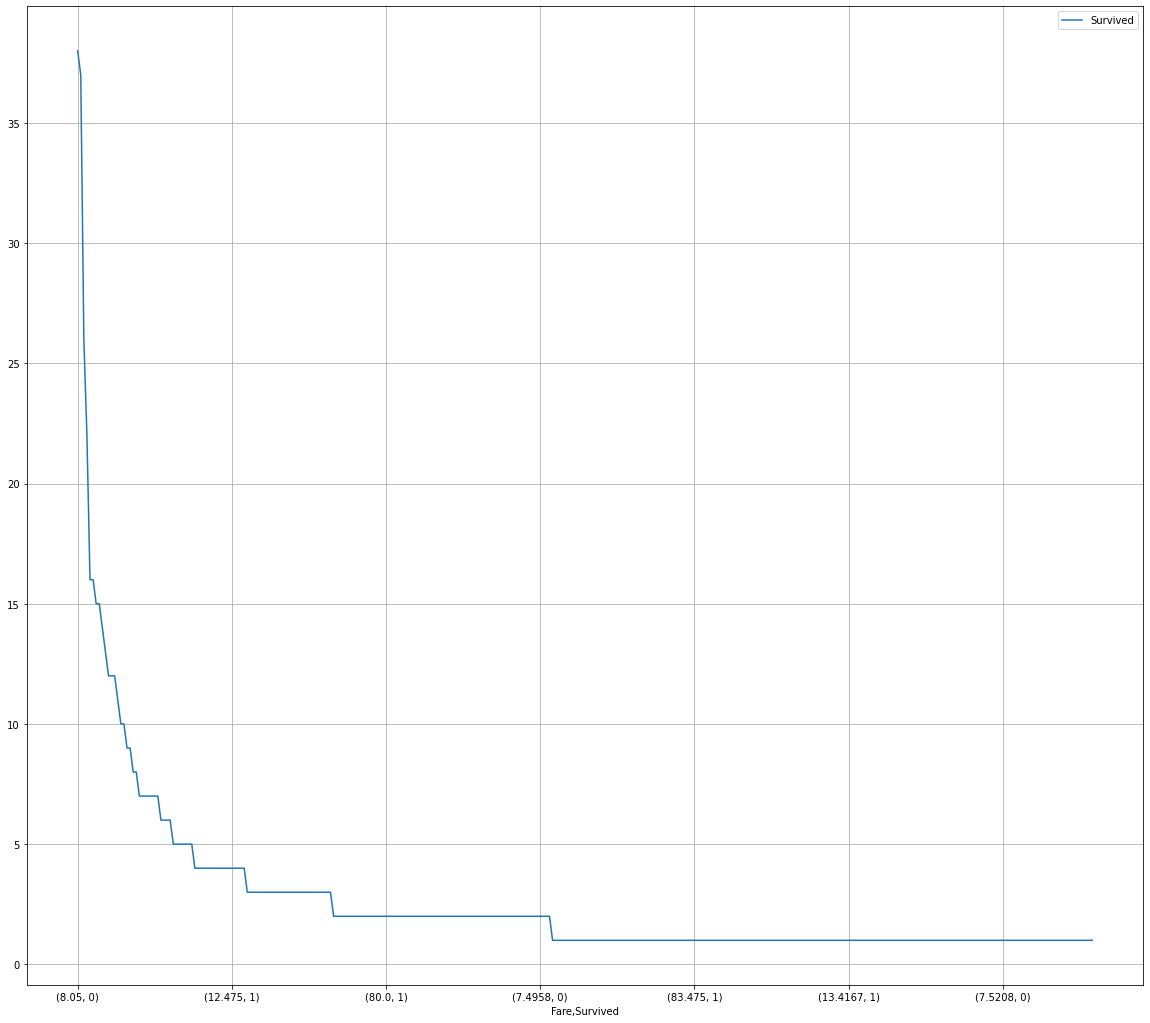

In [27]:
# 计算不同票价中生存与死亡人数 1表示生存，0表示死亡
fare_sur = text.groupby(['Fare'])['Survived'].value_counts().sort_values(ascending=False)
# 排序后绘折线图
fig = plt.figure(figsize=(20, 18))
fare_sur.plot(grid=True)
plt.legend()
plt.show()

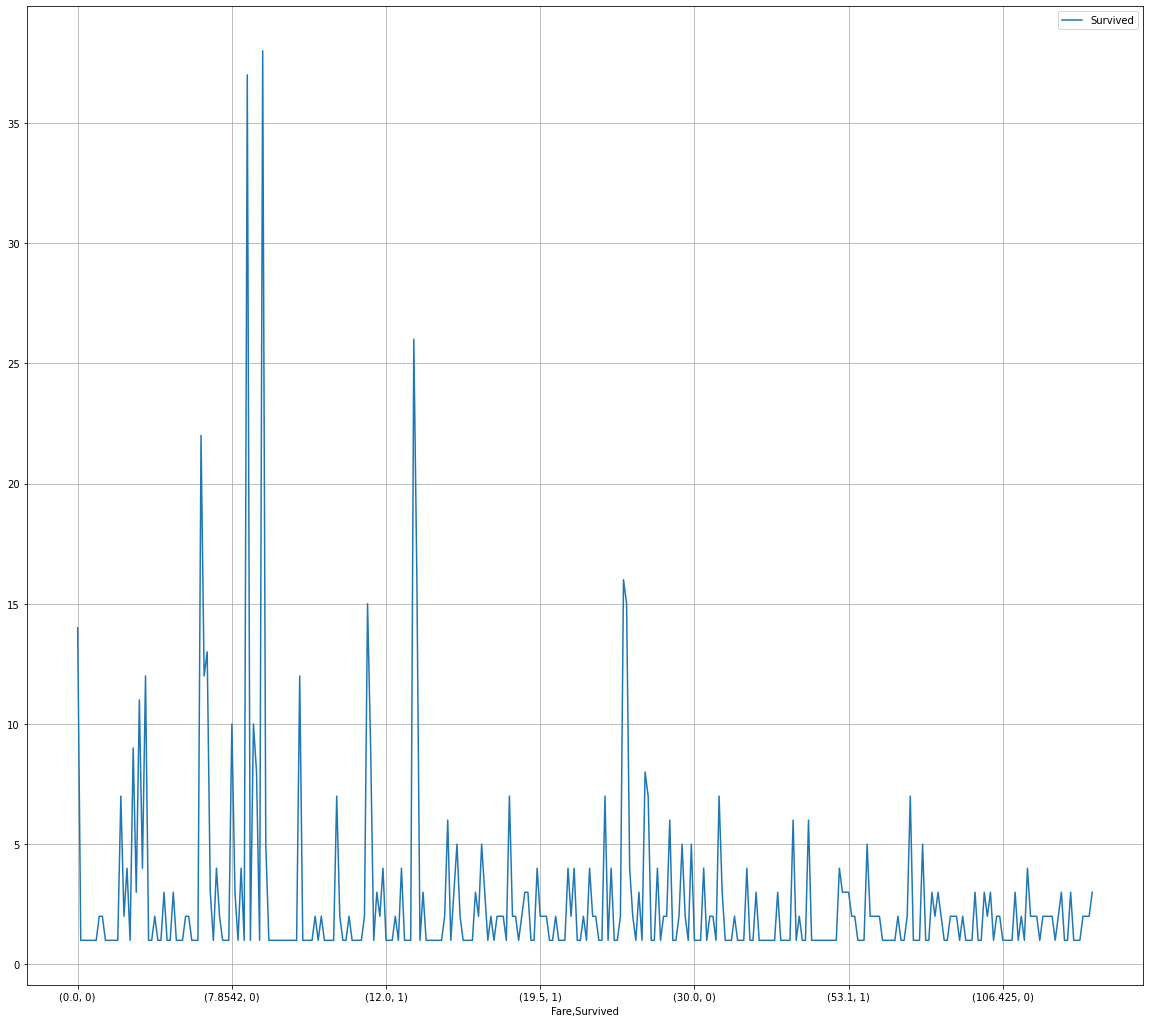

In [28]:
# 排序前绘折线图
fare_sur1 = text.groupby(['Fare'])['Survived'].value_counts()
fig = plt.figure(figsize=(20, 18))
fare_sur1.plot(grid=True)
plt.legend()
plt.show()

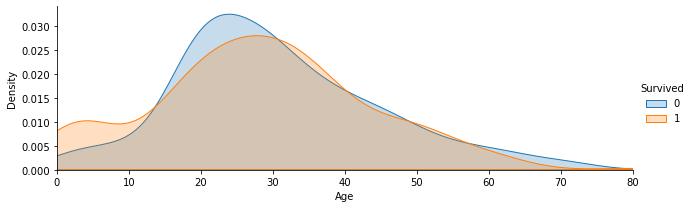

In [30]:
#可视化展示泰坦尼克号数据集中不同年龄的人生存与死亡人数分布情况。
import seaborn as sns
facet = sns.FacetGrid(text, hue="Survived",aspect=3)
facet.map(sns.kdeplot,'Age',shade= True)
facet.set(xlim=(0, text['Age'].max()))
facet.add_legend()

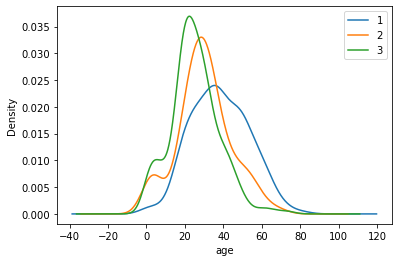

In [31]:
#可视化展示泰坦尼克号数据集中不同仓位等级的人年龄分布情况。
text.Age[text.Pclass == 1].plot(kind='kde')
text.Age[text.Pclass == 2].plot(kind='kde')
text.Age[text.Pclass == 3].plot(kind='kde')
plt.xlabel("age")
plt.legend((1,2,3),loc="best")